# T cell annotation
Lingting Shi, Azizi lab, Columbia University

In [2]:
from pathlib import Path
import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc

In [3]:
# Paths — relative to this notebook's location (GVHD_Reproducibility-main/Sc&TCR_Pipelines/)
PROJECT_ROOT = Path('../..')

# Input paths
TCELL_ANN_SC_PATH     = PROJECT_ROOT / 'adata_file' / 'tcell_ann_sc.h5ad'

# Output paths — figures
FIGURES_SC_DIR = PROJECT_ROOT / 'Figures' / 'single_cell_figures'
TCELL_ANN_CONCAT_PATH = PROJECT_ROOT / 'adata_file' / 'tcell_ann_concat_Tcell_only_proportion.h5ad'

In [4]:
tcell_ann_concat = anndata.read_h5ad(TCELL_ANN_SC_PATH)

In [5]:
tcell_ann_concat

AnnData object with n_obs × n_vars = 38539 × 38012
    obs: 'PatientID', 'SampleID', 'FreshorFrozen', 'Days_post-Transplant', 'Tissue_Location', 'LPorIE', 'Enrichment Method', 'Pathological_grade_of_GVHD', 'Grade_num', 'GVHD_Grade_1', 'GVHD_Grade_2', 'GVHD_Grade_3', 'Transplant_Conditioning', 'Gender', 'DoT', 'Time_1stGVHD', 'Donor', 'Disease', 'GVHD_Prophylaxis_Regimen', 'Dates_from_Transplantation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'is_doublet', 'leiden', 'leiden_0.15', 'B_doublet', 'Myeloid_doublet', 'Macrophage_doublet', 'Monocyte_doublet', 'Epithelial_doublet', 'Fibroblast_doublet', 'plasma_doublet2', 'if_doublet', 'T_cell_subsets'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'B_doublet_colors', 'Epithelial_doublet_colors', 'Fibroblast_doublet_colors', 'Macropha

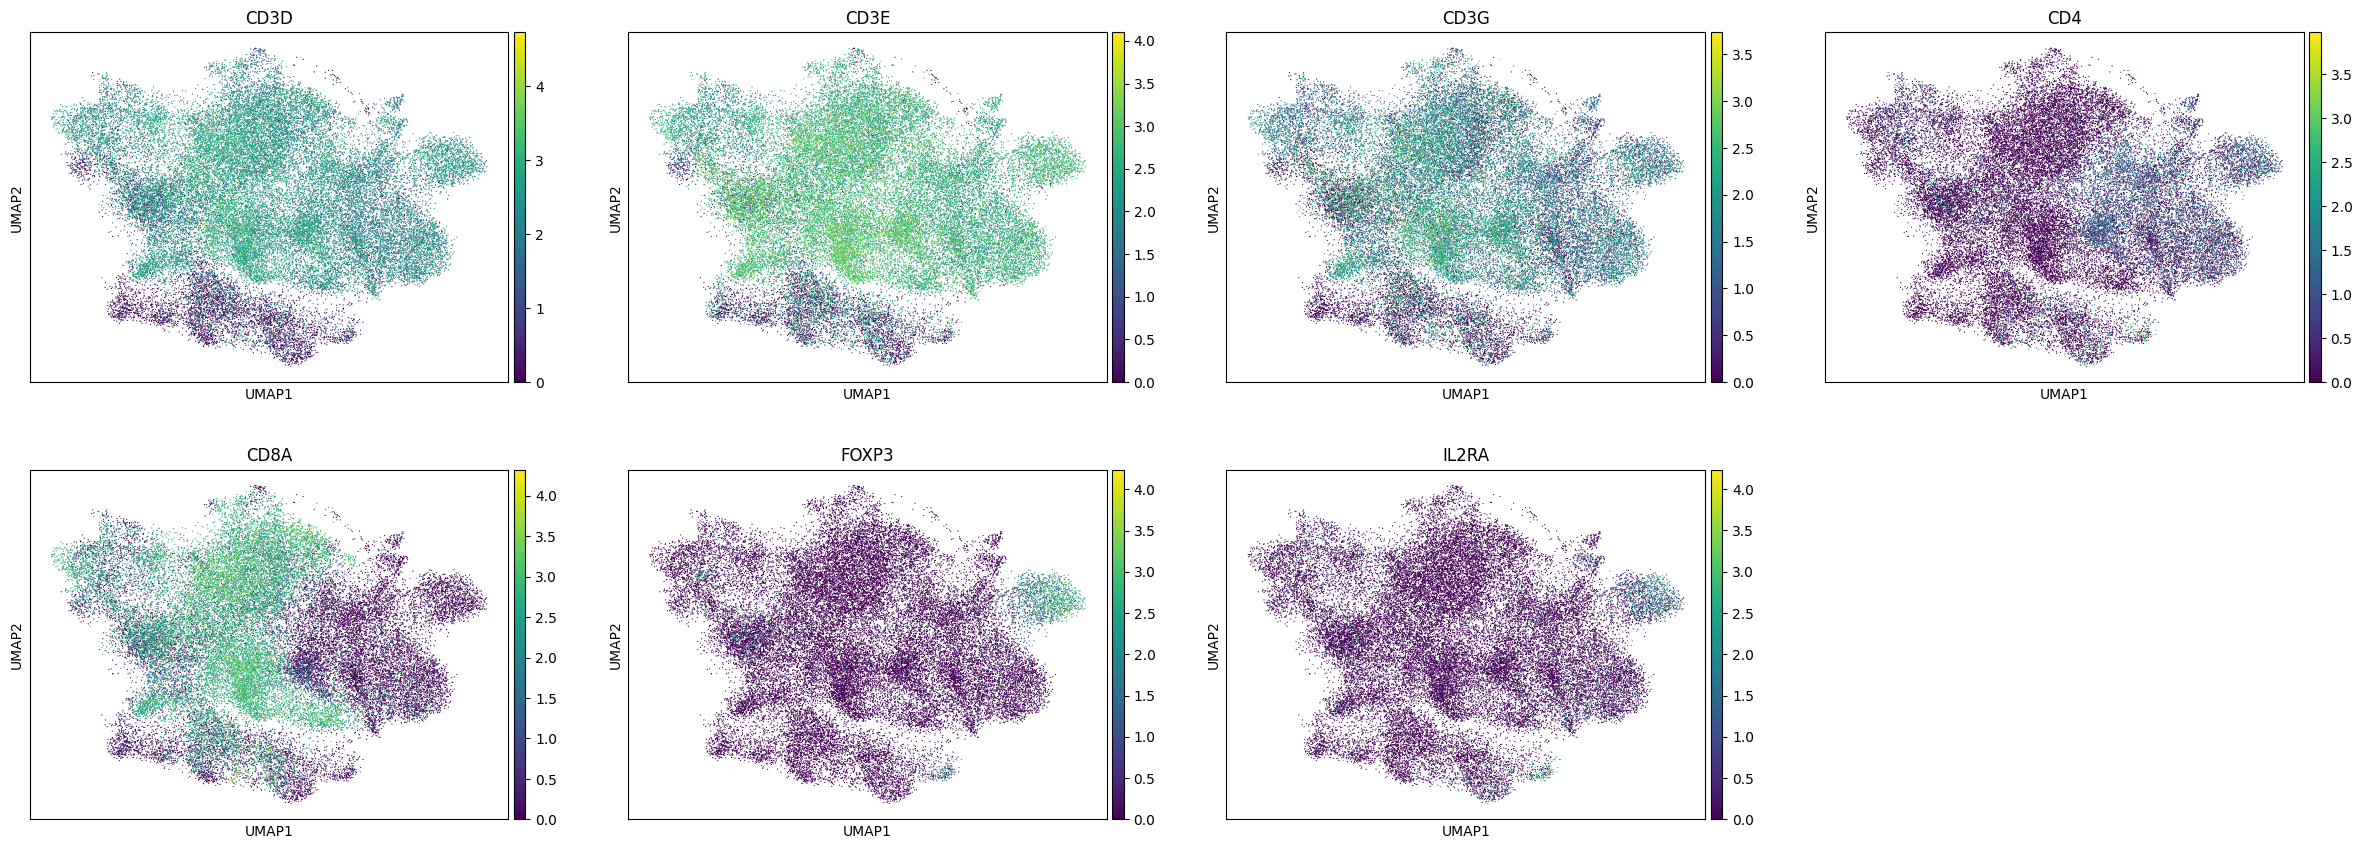

In [6]:
sc.pl.umap(tcell_ann_concat, color=["CD3D","CD3E","CD3G", 'CD4', 'CD8A','FOXP3','IL2RA'])

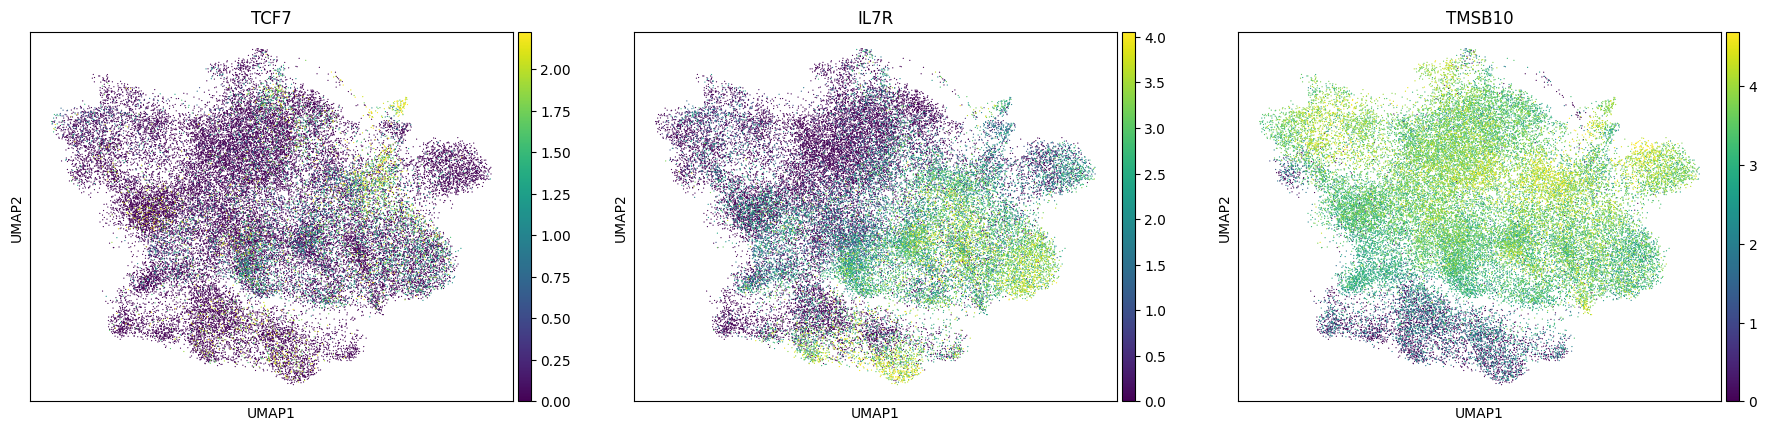

In [8]:
import numpy as np
sc.pl.umap(tcell_ann_concat, color=["TCF7", "IL7R", "TMSB10"], cmap='viridis', vmax=lambda x: np.quantile(x, 0.99))

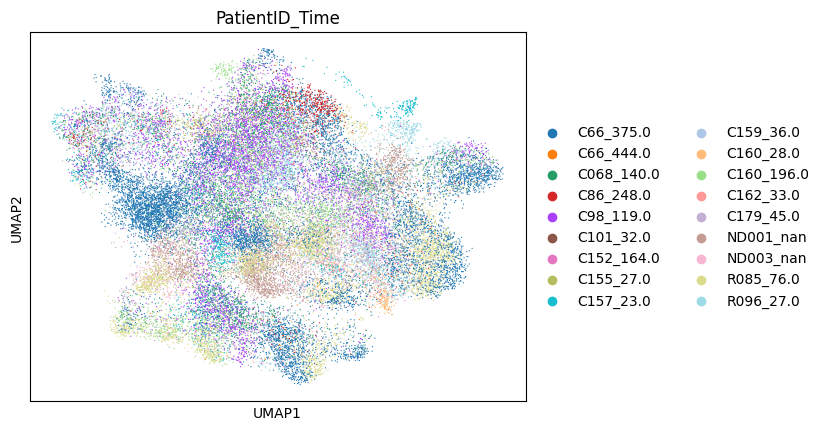

In [6]:
tcell_ann_concat.obs['GVHD_Grade_1'] = tcell_ann_concat.obs['GVHD_Grade_1'].astype('category')
tcell_ann_concat.obs['PatientID_Time'] = tcell_ann_concat.obs['PatientID'].astype(str)+'_'+tcell_ann_concat.obs['Days_post-Transplant'].astype(str)

sc.pl.umap(tcell_ann_concat, color=['PatientID_Time'],ncols=2)

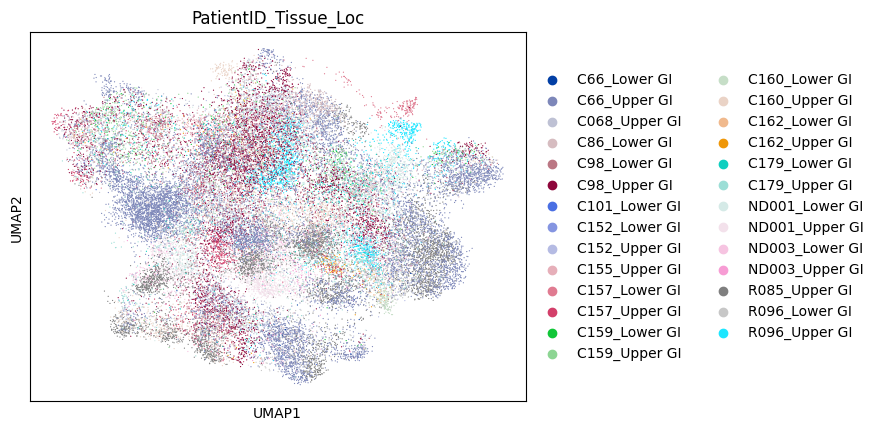

In [7]:
tcell_ann_concat.obs['PatientID_Tissue_Loc'] = tcell_ann_concat.obs['PatientID'].astype(str)+'_'+tcell_ann_concat.obs['Tissue_Location'].astype(str)

tcell_ann_concat.obs['PatientID_Grade'] = tcell_ann_concat.obs['PatientID'].astype(str)+'_'+tcell_ann_concat.obs['GVHD_Grade_1'].astype(str)

sc.pl.umap(tcell_ann_concat, color=['PatientID_Tissue_Loc'],ncols=2)

In [8]:
tcell_ann_concat.obs['PatientID_Grade_Time_Loc'] = tcell_ann_concat.obs['PatientID'].astype(str)+'_'+tcell_ann_concat.obs['GVHD_Grade_1'].astype(str)+'_'+tcell_ann_concat.obs['Days_post-Transplant'].astype(str)+'_'+tcell_ann_concat.obs['Tissue_Location'].astype(str)

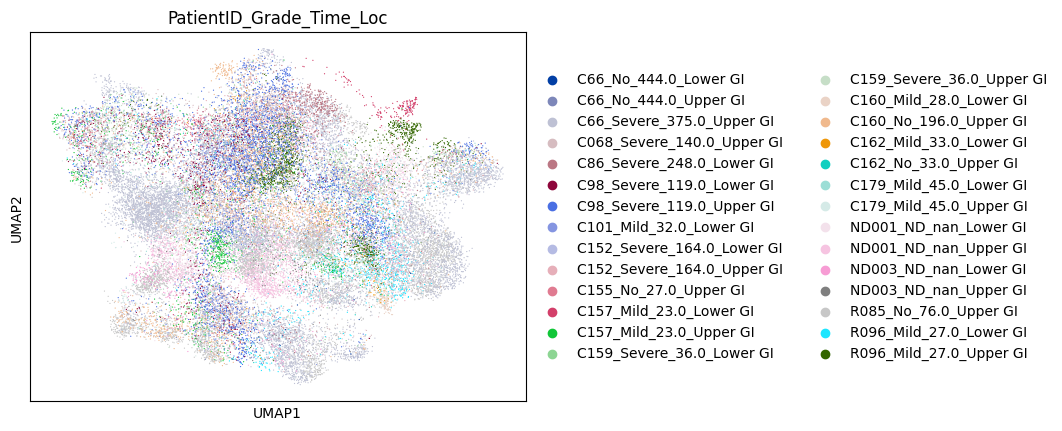

In [9]:
sc.pl.umap(tcell_ann_concat, color=['PatientID_Grade_Time_Loc'],ncols=2)

# Figure 4C

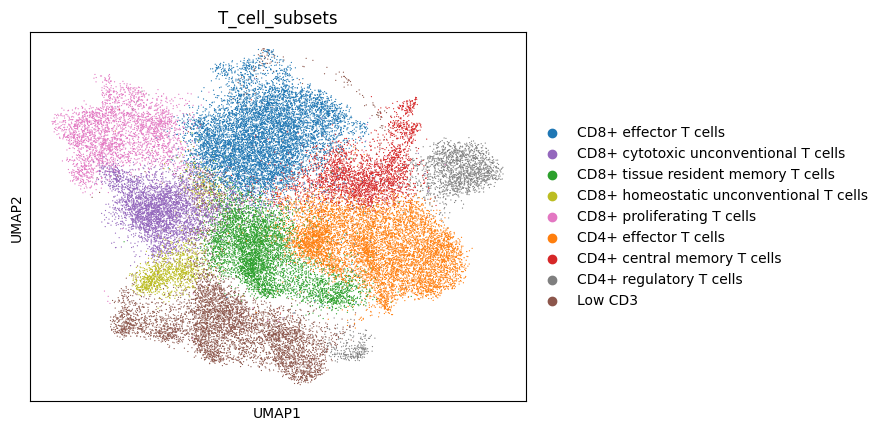

In [10]:
sc.pl.umap(tcell_ann_concat, color=["T_cell_subsets"], ncols=2)

In [11]:
import pandas as pd

oldcol = "T_cell_subsets"
newcol = "T_cell_subsets_plot"

# Your desired plotting order / labels
new_cluster_names = [
    'CD8+ effector T cells',
    'CD4+ effector T cells',
    'CD8+ tissue resident \nmemory T cells',
    "CD4+ \ncentral memory T cells",
    "CD8+ cytotoxic \nunconventional T cells",
    'Low CD3',
    "CD8+ \nproliferating T cells",
    "CD4+ \nregulatory T cells",
    'CD8+ homeostatic \nunconventional T cells'
]

# 1) start from the existing labels
tcell_ann_concat.obs[newcol] = tcell_ann_concat.obs[oldcol].astype(str)

# 2) map old -> new (edit the LEFT side to match your current categories exactly)
rename_map = {
    "CD8+ effector T cells": "CD8+ effector T cells",
    "CD4+ effector T cells": "CD4+ effector T cells",
    "CD8+ tissue resident memory T cells": "CD8+ tissue resident \nmemory T cells",
    "CD4+ central memory T cells": "CD4+ \ncentral memory T cells",
    "CD8+ cytotoxic unconventional T cells": "CD8+ cytotoxic \nunconventional T cells",
    "Low CD3": "Low CD3",
    "CD8+ proliferating T cells": "CD8+ \nproliferating T cells",
    "CD4+ regulatory T cells": "CD4+ \nregulatory T cells",
    "CD8+ homeostatic unconventional T cells": "CD8+ homeostatic \nunconventional T cells",
}

tcell_ann_concat.obs[newcol] = tcell_ann_concat.obs[newcol].replace(rename_map)

# 3) enforce category order for plotting / legends
tcell_ann_concat.obs[newcol] = pd.Categorical(
    tcell_ann_concat.obs[newcol],
    categories=new_cluster_names,
    ordered=True
)

# (optional) quick sanity check: any labels that didn't get mapped?
unmapped = set(tcell_ann_concat.obs[newcol].unique()) - set(new_cluster_names)
print("Unmapped labels in plot column:", unmapped)

Unmapped labels in plot column: set()


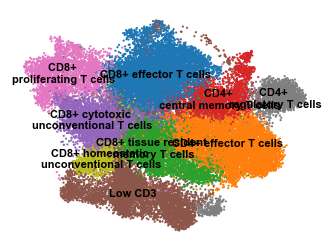

In [12]:
import matplotlib as mpl
# Update your existing rcParams
mpl.rcParams.update({
    'font.size': 8,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (4, 3)  # Set default figure size to 6×4 inches
})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size


# # New cluster names
# new_cluster_names = ['CD8+ Effector T cells','CD4+ Effector T cells','CD8+ Tissue Resident \nMemory T cells', "CD4+ \nCentral Memory T cells","CD8+ Cytotoxic \nUnconventional T cells",'Low CD3',"CD8+ \nProliferatingT cells","CD4+ Regulatory T cells",'CD8+ Homeostatic \nUnconventional T cells '
# ]

# # Rename clusters
# tcell_ann_concat.rename_categories('leiden_0.5', new_cluster_names)

# Generate UMAP plot with larger dots
sc.pl.umap(
    tcell_ann_concat,
    color="T_cell_subsets_plot",
    legend_loc='on data',
    title='',
    frameon=False,
    size=10,  # Adjust this value to make the dots bigger (default is 120)
    show=False  # We will save it manually
)

# # Save the plot manually with DPI 300
plt.savefig(FIGURES_SC_DIR / 'umap_clusters_dpi300.pdf', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig(FIGURES_SC_DIR / 'umap_clusters_dpi300.png', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig(FIGURES_SC_DIR / 'umap_clusters_dpi300.svg', dpi=300, bbox_inches='tight', transparent = True)
# Show the plot (optional, if you want to see it before saving)
plt.show()

In [13]:
###### Filter out samples with low cell count
# Calculate cell counts per sample
cell_counts = tcell_ann_concat.obs['SampleID'].value_counts()

# Get samples with at least 100 cells
valid_samples = cell_counts[cell_counts >= 100].index

# Subset AnnData to retain only valid samples
tcell_ann_concat_f = tcell_ann_concat[tcell_ann_concat.obs['SampleID'].isin(valid_samples), :]

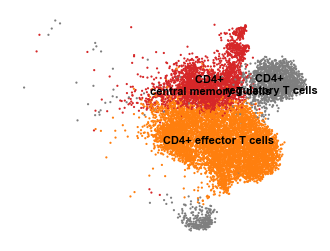

In [14]:
# Generate UMAP plot with larger dots
sc.pl.umap(
    tcell_ann_concat_f[tcell_ann_concat_f.obs["T_cell_subsets"].isin(['CD4+ effector T cells',"CD4+ regulatory T cells",  "CD4+ central memory T cells"])],
    color="T_cell_subsets_plot",
    legend_loc='on data',
    title='',
    frameon=False,
    size=10,  # Adjust this value to make the dots bigger (default is 120)
    show=False  # We will save it manually
)

# Save the plot manually with DPI 300
plt.savefig(FIGURES_SC_DIR / f'umap_clusters_cd4_dpi300.pdf', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig(FIGURES_SC_DIR / f'umap_clusters_cd4_dpi300.png', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig(FIGURES_SC_DIR / f'umap_clusters_cd4_dpi300.svg', dpi=300, bbox_inches='tight', transparent = True)
# Show the plot (optional, if you want to see it before saving)
plt.show()

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_81023/835454442.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  tcell_ann_concat_f.obs["GVHD_Grade_1"] = pd.Categorical(


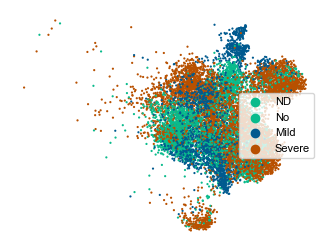

In [15]:

# Define the order you want
desired_order = ['ND','No', 'Mild', 'Severe']  # Adjust based on your data

# Convert to categorical with specified order
tcell_ann_concat_f.obs["GVHD_Grade_1"] = pd.Categorical(
    tcell_ann_concat_f.obs["GVHD_Grade_1"],
    categories=desired_order,
    ordered=True
)
tcell_ann_concat_f.uns["GVHD_Grade_1_colors"] = ['#09BB8C','#09BB8C','#005A8F', '#B85000']
# Generate UMAP plot with larger dots
sc.pl.umap(
    tcell_ann_concat_f[tcell_ann_concat_f.obs["T_cell_subsets"].isin(['CD4+ effector T cells',"CD4+ regulatory T cells",  "CD4+ central memory T cells"])],
    color='GVHD_Grade_1',
    legend_loc='right',
    title='',
    frameon=False,
    size=10,  # Adjust this value to make the dots bigger (default is 120)
    show=False  # We will save it manually
)

# Save the plot manually with DPI 300
plt.savefig(FIGURES_SC_DIR / f'umap_clusters_cd4_grade_dpi300.pdf', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig(FIGURES_SC_DIR / f'umap_clusters_cd4_grade_dpi300.png', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig(FIGURES_SC_DIR / f'umap_clusters_cd4_grade_dpi300.svg', dpi=300, bbox_inches='tight', transparent = True)
# Show the plot (optional, if you want to see it before saving)
plt.show()

# Figure 4F

In [16]:
category_order = ['ND', 'No', 'Mild', 'Severe']

ND


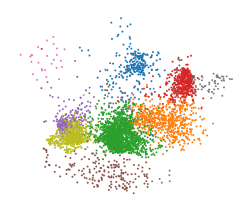

No


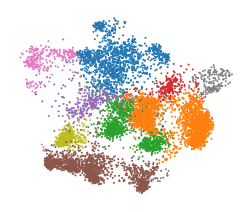

Mild


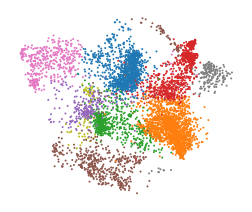

Severe


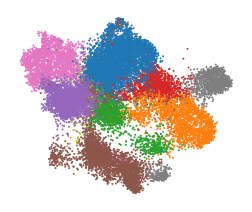

In [17]:
import matplotlib as mpl
# Update your existing rcParams
mpl.rcParams.update({
    'font.size': 8,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (3, 2.5)  # Set default figure size to 6×4 inches
})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size

for cat in category_order:
    print(cat)
    # Generate UMAP plot with larger dots and transparency
    sc.pl.umap(
        tcell_ann_concat[tcell_ann_concat.obs['GVHD_Grade_1']== cat],
        color="T_cell_subsets",
        title='',
        frameon=False,
        size=8,  # Adjust this value to make the dots bigger (default is 120)
        show=False,  # We will save it manually
        legend_loc=None
    )

    # Save the plot manually with DPI 300
    plt.savefig(FIGURES_SC_DIR / f'umap_clusters_dpi300_presentation_{cat}.pdf', dpi=300, bbox_inches='tight', transparent = True)
    plt.savefig(FIGURES_SC_DIR / f'umap_clusters_dpi300_presentation_{cat}.png', dpi=300, bbox_inches='tight', transparent = True)
    plt.savefig(FIGURES_SC_DIR / f'umap_clusters_dpi300_presentation_{cat}.svg', dpi=300, bbox_inches='tight', transparent = True)
# Show the plot (optional, if you want to see it before saving)
    plt.show()

Intraepithelial Cells


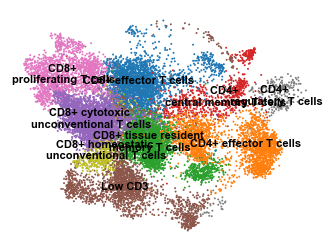

Lamina Propria Cells


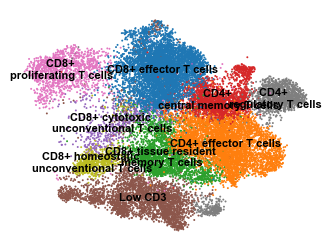

In [18]:
import matplotlib as mpl
# Update your existing rcParams
mpl.rcParams.update({
    'font.size': 8,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (4, 3)  # Set default figure size to 6×4 inches
})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size

category_order = ['Intraepithelial Cells', 'Lamina Propria Cells']

for cat in category_order:
    print(cat)
    # Generate UMAP plot with larger dots and transparency
    sc.pl.umap(
        tcell_ann_concat[tcell_ann_concat.obs["LPorIE"]== cat],
        color="T_cell_subsets_plot",
        title='',
        frameon=False,
        size=8,  # Adjust this value to make the dots bigger (default is 120)
        show=False,  # We will save it manually
        legend_loc="on data"
    )

    # Save the plot manually with DPI 300
    plt.savefig(FIGURES_SC_DIR / f'umap_clusters_dpi300_presentation_{cat}.pdf', dpi=300, bbox_inches='tight', transparent = True)
    plt.savefig(FIGURES_SC_DIR / f'umap_clusters_dpi300_presentation_{cat}.png', dpi=300, bbox_inches='tight', transparent = True)
    plt.savefig(FIGURES_SC_DIR / f'umap_clusters_dpi300_presentation_{cat}.svg', dpi=300, bbox_inches='tight', transparent = True)
# Show the plot (optional, if you want to see it before saving)
    plt.show()

# Heatmaps and dot plots for each cluster

# Figure 4F

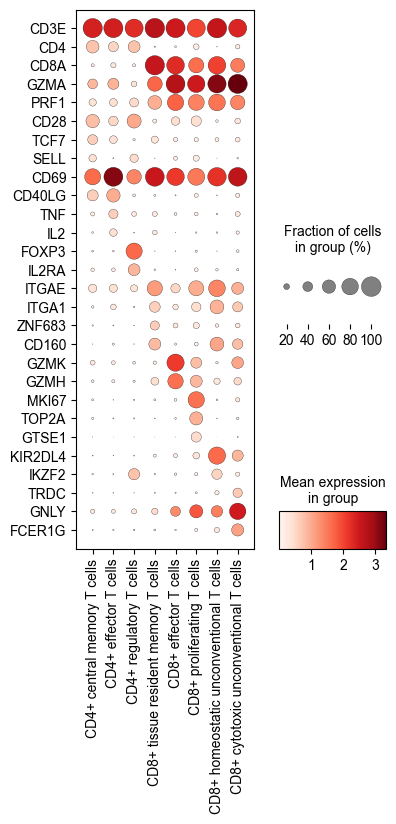

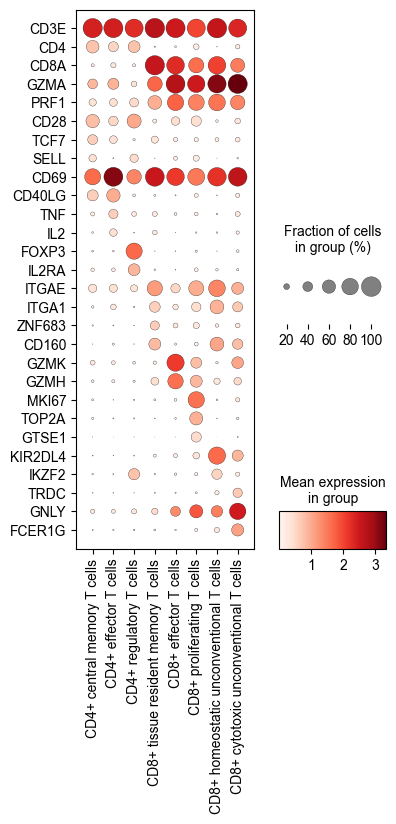

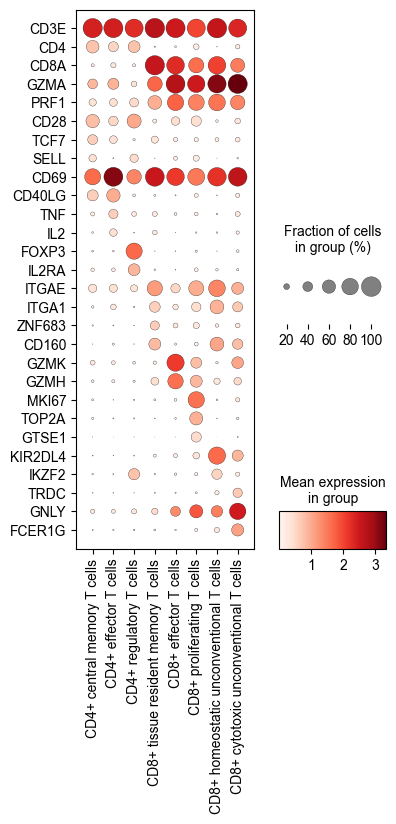

In [19]:
import pandas as pd

# Specify the desired order
desired_order = ["CD4+ central memory T cells",'CD4+ effector T cells', "CD4+ regulatory T cells", 'CD8+ tissue resident memory T cells',"CD8+ effector T cells", "CD8+ proliferating T cells",'CD8+ homeostatic unconventional T cells', "CD8+ cytotoxic unconventional T cells"]

# Reorder the categories in the `groupby` column
tcell_ann_concat.obs['T_cell_subsets_reordered'] = tcell_ann_concat.obs['T_cell_subsets'].astype(pd.CategoricalDtype(categories=desired_order, ordered=True))

## For publication
import matplotlib as mpl
import matplotlib as mpl
# Update your existing rcParams
mpl.rcParams.update({
    'font.size': 12,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    #'figure.figsize': (4, 3),  # Set default figure size to 6×4 inches
    'lines.linewidth': 1.2  # Set default line width to 1
})
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['xtick.labelsize'] = 12  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 12  # Colorbar tick label size


# Plot each marker set one at a time and save the figures manually
# Generate the dot plot and return the figure
dotplot = sc.pl.dotplot(
    tcell_ann_concat[tcell_ann_concat.obs["T_cell_subsets"] != 'Low CD3'], 
    var_names=["CD3E",'CD4','CD8A',"GZMA",'PRF1','CD28', 'TCF7','SELL','CD69', 'CD40LG', 'TNF', 'IL2', "FOXP3",'IL2RA','ITGAE', 'ITGA1','ZNF683', 'CD160','GZMK','GZMH','MKI67', 'TOP2A','GTSE1', 'KIR2DL4', 'IKZF2', 'TRDC', 'GNLY', 'FCER1G'], 
    groupby='T_cell_subsets_reordered', 
    dendrogram=False, 
    title='',
    return_fig=True,  # Return the figure object for saving
    swap_axes=True,
    figsize=(4,7),
    dot_max = 1

)

    
# Save the figure with the specified DPI
dotplot.savefig(FIGURES_SC_DIR / 'dotplot_cluster_sign_presentation.png', dpi=300, bbox_inches='tight')
dotplot.savefig(FIGURES_SC_DIR / 'dotplot_cluster_sign_presentation.pdf', dpi=300, bbox_inches='tight')
dotplot.savefig(FIGURES_SC_DIR / 'dotplot_cluster_sign_presentation.svg', dpi=300, bbox_inches='tight')
# Show the plot (optional)

plt.show()

                  T_cell_subsets_reordered
0              CD4+ central memory T cells
1                    CD4+ effector T cells
2                  CD4+ regulatory T cells
3      CD8+ tissue resident memory T cells
4                    CD8+ effector T cells
5               CD8+ proliferating T cells
6  CD8+ homeostatic unconventional T cells
7    CD8+ cytotoxic unconventional T cells


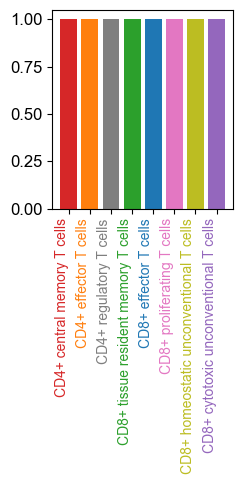

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
mpl.rcParams.update({
    'font.size': 12,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (2.5, 5),  # Set default figure size to 6×4 inches
    'lines.linewidth': 1.2  # Set default line width to 1
})

# Create a mock observation dataframe
# Replace this with your actual data from `tcell_ann_concat.obs`
obs_data = pd.DataFrame({
    'T_cell_subsets_reordered': desired_order
})

print(obs_data)

# Map of categories to colors
color_map = {
    'CD8+ effector T cells': '#1f77b4',
    'CD4+ effector T cells': '#ff7f0e',
    'CD8+ tissue resident memory T cells': '#2ca02c',
    'CD4+ central memory T cells': '#d62728',
    'CD8+ cytotoxic unconventional T cells': '#9467bd',
    'Low CD3': '#8c564b',
    'CD8+ proliferating T cells': '#e377c2',
    'CD4+ regulatory T cells': '#7f7f7f',
    'CD8+ homeostatic unconventional T cells': '#bcbd22'
}

# Set y as 1 for all
x = obs_data['T_cell_subsets_reordered']
y = [1] * len(x)  # y-values all set to 1
colors = [color_map[category] for category in x]  # Map colors based on categories

# Create the plot
fig, ax = plt.subplots(figsize=(2.5, 5))
bars = ax.bar(x, y, color=colors)  # Assign bar colors

# Rotate x-axis labels, set colors, and adjust layout
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, rotation=90, ha='right')  # Rotate labels

# Color the x-axis labels individually
for label, color in zip(ax.get_xticklabels(), colors):
    label.set_color(color)  # Set label color
plt.xticks(fontsize=10)
plt.tight_layout()
# Save the figure with the specified DPI
plt.savefig(FIGURES_SC_DIR / 'dotplot_x-axis_label.png', dpi=900, bbox_inches='tight')
plt.savefig(FIGURES_SC_DIR / 'dotplot_x-axis_label.pdf', dpi=900, bbox_inches='tight')
plt.savefig(FIGURES_SC_DIR / 'dotplot_x-axis_label.svg', dpi=900, bbox_inches='tight')


# Show the plot
plt.show()


In [21]:
tcell_ann_concat.write(TCELL_ANN_CONCAT_PATH)